In [13]:
from __future__ import annotations
from pathlib import Path
from typing import Iterable

import pandas as pd

INPUT_PATH = "news_all1.parquet"

REQUIRED_COLUMNS = [
    "link",
    "domain",
    "category",
    "title",
    "description",
    "keywords",
    "author",
    "publication_date",
    "year",
]

TEXT_COLUMNS = [
    "link",
    "domain",
    "category",
    "title",
    "description",
    "keywords",
    "author",
]

NULL_LIKE_VALUES = {"", "null", "nan", "none"}


def load_input_data(path: str | Path) -> pd.DataFrame:
    source_path = Path(path)
    if not str(source_path).strip():
        raise ValueError("Set INPUT_PATH before running this script.")
    if not source_path.exists():
        raise FileNotFoundError(f"Input file not found: {source_path}")

    if source_path.suffix.lower() == ".csv":
        df = pd.read_csv(source_path)
    elif source_path.suffix.lower() == ".parquet":
        df = pd.read_parquet(source_path)
    else:
        raise ValueError("INPUT_PATH must point to a .csv or .parquet file.")

    df.columns = [str(column).strip().lower() for column in df.columns]
    return df


def validate_required_columns(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")


def normalize_text_columns(df: pd.DataFrame, text_columns: Iterable[str]) -> pd.DataFrame:
    out = df.copy()
    for column in text_columns:
        out[column] = out[column].astype("string")
        out[column] = out[column].str.replace(r"\s+", " ", regex=True).str.strip()
    return out


def build_missing_mask(series: pd.Series) -> pd.Series:
    if pd.api.types.is_string_dtype(series) or str(series.dtype) in {"object", "string"}:
        text_series = series.astype("string").str.strip()
        return text_series.isna() | text_series.fillna("").str.lower().isin(NULL_LIKE_VALUES)
    return series.isna()


def build_missing_report(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    records = []
    for column in columns:
        missing_mask = build_missing_mask(df[column])
        records.append(
            {
                "column": column,
                "number_of_missing_rows": int(missing_mask.sum()),
                "missing_pct": round(float(missing_mask.mean() * 100), 2),
            }
        )
    return pd.DataFrame(records)


def prepare_dates_and_year(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["publication_date_raw"] = out["publication_date"]
    out["publication_date"] = pd.to_datetime(out["publication_date"], errors="coerce")
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out["year_from_publication_date"] = out["publication_date"].dt.year.astype("Int64")
    out["publication_date_invalid_flag"] = out["publication_date"].isna()
    out["year_mismatch_flag"] = (
        out["publication_date"].notna()
        & out["year"].notna()
        & out["year_from_publication_date"].notna()
        & out["year"].ne(out["year_from_publication_date"])
    )
    return out


def build_duplicate_link_date_rows(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.loc[df.duplicated(subset=["link", "publication_date"], keep=False)]
        .sort_values(["link", "publication_date"], kind="mergesort")
        .reset_index(drop=True)
    )


def build_unique_value_counts(df: pd.DataFrame, column: str) -> pd.DataFrame:
    valid_mask = ~build_missing_mask(df[column])
    summary = (
        df.loc[valid_mask, column]
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="row_count")
        .sort_values(["row_count", column], ascending=[False, True], kind="mergesort")
        .reset_index(drop=True)
    )
    return summary


def build_domain_missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    valid_domain_mask = ~build_missing_mask(out["domain"])
    out = out.loc[valid_domain_mask].copy()

    keywords_missing_mask = build_missing_mask(out["keywords"])
    description_missing_mask = build_missing_mask(out["description"])

    summary = (
        out.groupby("domain", dropna=False)
        .agg(
            row_count=("domain", "size"),
            missing_keywords_rows=("keywords", lambda s: int(build_missing_mask(s).sum())),
            missing_description_rows=("description", lambda s: int(build_missing_mask(s).sum())),
        )
        .reset_index()
        .sort_values(["row_count", "domain"], ascending=[False, True], kind="mergesort")
        .reset_index(drop=True)
    )

    summary["missing_keywords_pct"] = (
        (summary["missing_keywords_rows"] / summary["row_count"]) * 100
    ).round(2)
    summary["missing_description_pct"] = (
        (summary["missing_description_rows"] / summary["row_count"]) * 100
    ).round(2)
    return summary


def build_year_domain_record_matrix(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["analysis_year"] = out["year_from_publication_date"].where(
        out["year_from_publication_date"].notna(),
        out["year"],
    )

    valid_mask = out["analysis_year"].notna() & (~build_missing_mask(out["domain"]))
    matrix = (
        out.loc[valid_mask, ["analysis_year", "domain"]]
        .assign(analysis_year=lambda frame: frame["analysis_year"].astype("Int64"))
        .groupby(["analysis_year", "domain"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    matrix.index.name = "year"
    return matrix.reset_index()


def clean_basic(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.drop_duplicates(subset=["link", "publication_date"], keep="first").copy()
    out = out.sort_values(["publication_date", "link"], kind="mergesort").reset_index(drop=True)
    return out


def print_preview(title: str, df: pd.DataFrame, rows: int = 10) -> None:
    print(f"\n{title}:")
    if df.empty:
        print("Empty")
        return
    print(df.head(rows).to_string(index=False))


def main() -> None:
    raw_df = load_input_data(INPUT_PATH)
    validate_required_columns(raw_df, REQUIRED_COLUMNS)

    input_rows = len(raw_df)
    normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
    prepared_df = prepare_dates_and_year(normalized_df)

    missing_report = build_missing_report(prepared_df, REQUIRED_COLUMNS)
    duplicate_rows = build_duplicate_link_date_rows(prepared_df)
    year_mismatch_rows = (
        prepared_df.loc[prepared_df["year_mismatch_flag"]]
        .sort_values(["publication_date", "link"], kind="mergesort")
        .reset_index(drop=True)
    )
    category_counts = build_unique_value_counts(prepared_df, "category")
    domain_counts = build_unique_value_counts(prepared_df, "domain")
    domain_missing_summary = build_domain_missing_summary(prepared_df)
    year_domain_record_matrix = build_year_domain_record_matrix(prepared_df)

    cleaned_df = clean_basic(prepared_df)

    print("Input rows:", input_rows)
    print("Rows after basic cleaning:", len(cleaned_df))
    print("Duplicate rows by link + publication_date:", len(duplicate_rows))
    print("Rows with invalid publication_date:", int(prepared_df["publication_date_invalid_flag"].sum()))
    print("Rows where publication_date year != year:", int(prepared_df["year_mismatch_flag"].sum()))
    print("Unique categories:", len(category_counts))
    print("Unique domains:", len(domain_counts))

    print_preview("Missing report", missing_report, rows=len(missing_report))
    print_preview(
        "Duplicate rows by link + publication_date",
        duplicate_rows[["link", "publication_date", "year", "title", "domain"]],
    )
    print_preview(
        "Rows where publication_date year != year",
        year_mismatch_rows[["link", "publication_date", "year", "year_from_publication_date", "title"]],
    )
    # print_preview("Category counts", category_counts, rows=len(category_counts))
    print_preview("Domain counts", domain_counts, rows=len(domain_counts))
    print_preview("Domain summary with missing keywords/description", domain_missing_summary, rows=len(domain_missing_summary))
    print_preview("Year-domain record matrix", year_domain_record_matrix, rows=len(year_domain_record_matrix))
    
if __name__ == "__main__":
    main()


Input rows: 60000
Rows after basic cleaning: 60000
Duplicate rows by link + publication_date: 0
Rows with invalid publication_date: 0
Rows where publication_date year != year: 0
Unique categories: 110
Unique domains: 7

Missing report:
          column  number_of_missing_rows  missing_pct
            link                       0         0.00
          domain                       0         0.00
        category                     109         0.18
           title                       0         0.00
     description                    1063         1.77
        keywords                   18154        30.26
          author                   12115        20.19
publication_date                       0         0.00
            year                       0         0.00

Duplicate rows by link + publication_date:
Empty

Rows where publication_date year != year:
Empty

Domain counts:
               domain  row_count
diendandoanhnghiep.vn      29278
   doanhnhansaigon.vn      26503
  https://

In [ ]:
raw_df = load_input_data(INPUT_PATH)
validate_required_columns(raw_df, REQUIRED_COLUMNS)
normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
prepared_df = prepare_dates_and_year(normalized_df)
category_counts = build_unique_value_counts(prepared_df, "category")
unique_categories = category_counts[["category"]].copy()
unique_categories.to_csv("unique_categories.csv", index=False, encoding="utf-8-sig")
df = pd.read_parquet("news_all1.parquet")

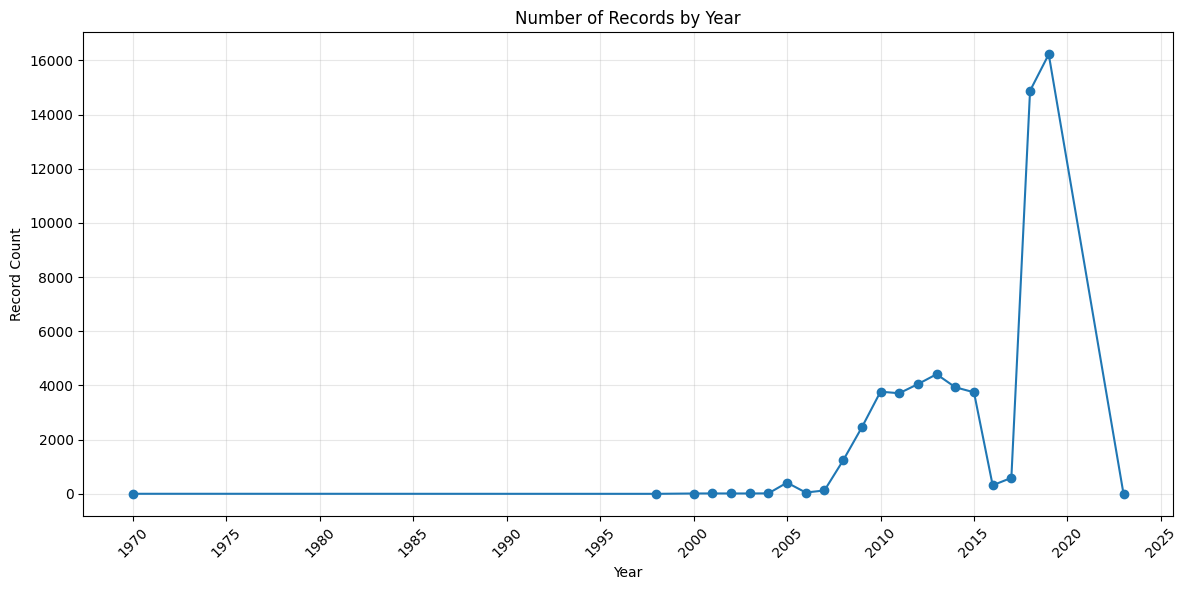

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

df = pd.read_parquet("news_all1.parquet")
year_counts = (
    df["year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values, marker="o")

plt.title("Number of Records by Year")
plt.xlabel("Year")
plt.ylabel("Record Count")

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(5))  # hiện mỗi 5 năm
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
year_counts 

year
1970        3
1998        1
2000       13
2001       15
2002       14
2003       14
2004       18
2005      414
2006       49
2007      125
2008     1234
2009     2452
2010     3772
2011     3714
2012     4051
2013     4416
2014     3935
2015     3749
2016      317
2017      590
2018    14878
2019    16225
2023        1
Name: count, dtype: int64

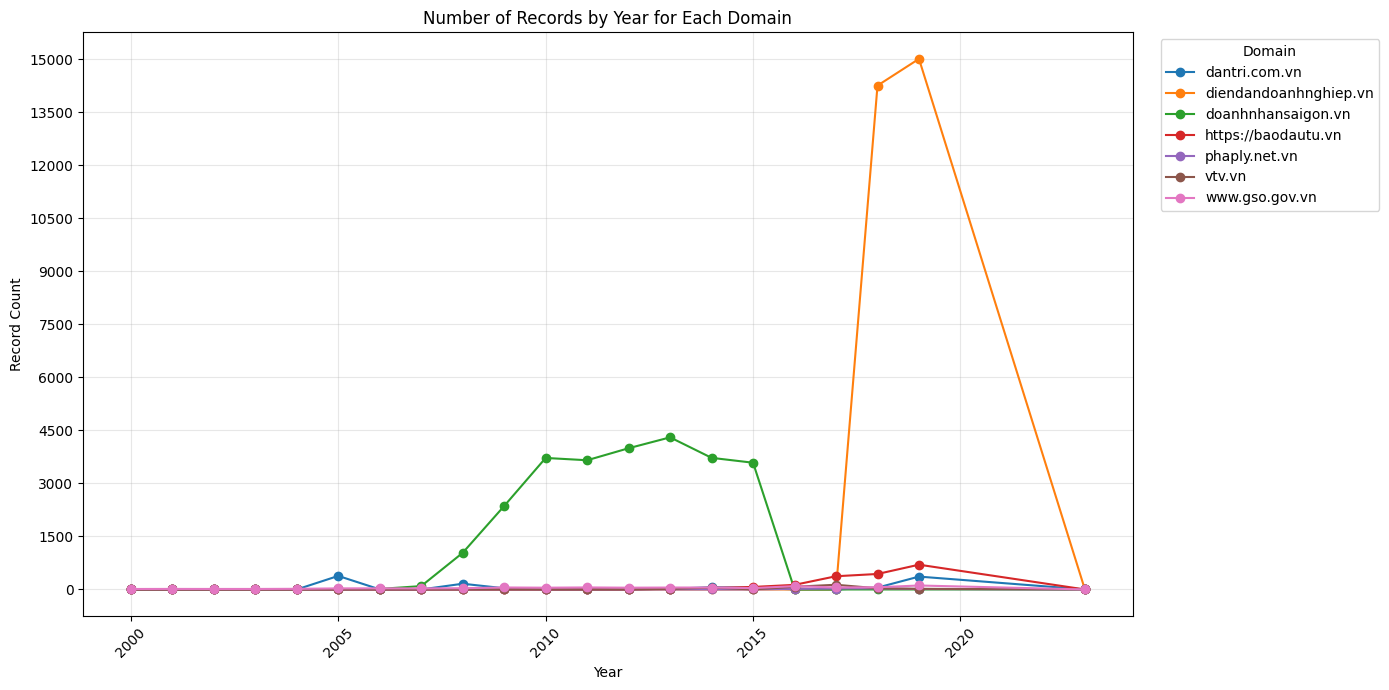

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plot_df = df.copy()
plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce")
plot_df = plot_df.dropna(subset=["year", "domain"])
plot_df["year"] = plot_df["year"].astype(int)

# Nếu muốn bỏ các năm quá dị
plot_df = plot_df[plot_df["year"] >= 2000]

year_domain_counts = (
    plot_df.groupby(["year", "domain"])
    .size()
    .reset_index(name="row_count")
)

pivot_df = year_domain_counts.pivot(
    index="year",
    columns="domain",
    values="row_count"
).fillna(0)

plt.figure(figsize=(14, 7))

for domain in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[domain], marker="o", label=domain)

plt.title("Number of Records by Year for Each Domain")
plt.xlabel("Year")
plt.ylabel("Record Count")

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(5))     # X mỗi 5 năm
ax.yaxis.set_major_locator(MultipleLocator(1500))  # Y mỗi 1500

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="Domain", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [24]:
df = pd.read_parquet("news_all1.parquet")
df.to_csv("news_all1.csv", index=False, encoding="utf-8-sig")

In [25]:
from __future__ import annotations
import ast
from pathlib import Path
import re
from typing import Iterable

import pandas as pd

INPUT_PATH = "news_all1.parquet"

TEXT_COLUMNS = [
    "link",
    "domain",
    "category",
    "title",
    "description",
    "keywords",
    "author",
]

NULL_LIKE_VALUES = {"", "null", "nan", "none"}


def load_input_data(path: str | Path) -> pd.DataFrame:
    source_path = Path(path)
    if not str(source_path).strip():
        raise ValueError("Set INPUT_PATH before running this script.")
    if not source_path.exists():
        raise FileNotFoundError(f"Input file not found: {source_path}")

    if source_path.suffix.lower() == ".csv":
        df = pd.read_csv(source_path)
    elif source_path.suffix.lower() == ".parquet":
        df = pd.read_parquet(source_path)
    else:
        raise ValueError("INPUT_PATH must point to a .csv or .parquet file.")

    return df


def normalize_text_columns(df: pd.DataFrame, text_columns: Iterable[str]) -> pd.DataFrame:
    out = df.copy()
    for column in text_columns:
        out[column] = out[column].astype("string")
        out[column] = out[column].str.replace(r"\s+", " ", regex=True).str.strip()
    return out


def normalize_domain_value(raw: object) -> object:
    if pd.isna(raw):
        return pd.NA

    text = str(raw).strip().lower()
    if text == "" or text in NULL_LIKE_VALUES:
        return pd.NA

    text = re.sub(r"^https?://", "", text)
    text = re.sub(r"^www\.", "", text)
    text = text.split("/", 1)[0]
    text = text.split("?", 1)[0]
    text = text.split("#", 1)[0]
    text = text.strip()
    return text if text else pd.NA


def normalize_domain_column(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["domain"] = out["domain"].apply(normalize_domain_value).astype("string")
    return out


def parse_dict_like_keywords(raw: object) -> object:
    if pd.isna(raw):
        return pd.NA

    if isinstance(raw, dict):
        keys = [str(key).strip() for key in raw.keys() if str(key).strip()]
        return ", ".join(keys) if keys else pd.NA

    text = str(raw).strip()
    if text == "" or text.lower() in NULL_LIKE_VALUES:
        return pd.NA
    if not (text.startswith("{") and text.endswith("}")):
        return text

    try:
        parsed = ast.literal_eval(text)
    except Exception:
        return text

    if isinstance(parsed, dict):
        keys = [str(key).strip() for key in parsed.keys() if str(key).strip()]
        return ", ".join(keys) if keys else pd.NA
    return text


def is_dict_like_keywords(raw: object) -> bool:
    if pd.isna(raw):
        return False

    if isinstance(raw, dict):
        return True

    text = str(raw).strip()
    if text == "" or text.lower() in NULL_LIKE_VALUES:
        return False
    if not (text.startswith("{") and text.endswith("}")):
        return False

    try:
        parsed = ast.literal_eval(text)
    except Exception:
        return False
    return isinstance(parsed, dict)


def normalize_keywords_column(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["keywords"] = out["keywords"].apply(parse_dict_like_keywords).astype("string")
    return out


def count_words_in_text(raw: object) -> int:
    if pd.isna(raw):
        return 0

    text = str(raw).strip()
    if text == "" or text.lower() in NULL_LIKE_VALUES:
        return 0

    return len(re.findall(r"\w+", text, flags=re.UNICODE))


def add_description_word_count(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["description_word_count"] = out["description"].apply(count_words_in_text)
    return out


def split_missing_description_rows(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    missing_mask = build_missing_mask(df["description"])
    missing_description_df = df.loc[missing_mask].copy().reset_index(drop=True)
    non_missing_description_df = df.loc[~missing_mask].copy().reset_index(drop=True)
    return non_missing_description_df, missing_description_df


def calculate_average_description_word_count(df: pd.DataFrame) -> float:
    if df.empty:
        return 0.0
    return round(float(df["description_word_count"].mean()), 2)


def calculate_description_word_count_percentiles(df: pd.DataFrame) -> dict[str, float]:
    series = df["description_word_count"].dropna()
    if series.empty:
        return {"p50": 0.0, "p90": 0.0}

    return {
        "p50": round(float(series.quantile(0.50)), 2),
        "p90": round(float(series.quantile(0.90)), 2),
    }


def build_missing_mask(series: pd.Series) -> pd.Series:
    if pd.api.types.is_string_dtype(series) or str(series.dtype) in {"object", "string"}:
        text_series = series.astype("string").str.strip()
        return text_series.isna() | text_series.fillna("").str.lower().isin(NULL_LIKE_VALUES)
    return series.isna()


def build_missing_report(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    records = []
    for column in columns:
        missing_mask = build_missing_mask(df[column])
        records.append(
            {
                "column": column,
                "number_of_missing_rows": int(missing_mask.sum()),
                "missing_pct": round(float(missing_mask.mean() * 100), 2),
            }
        )
    return pd.DataFrame(records)


def prepare_dates_and_year(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["publication_date_raw"] = out["publication_date"]
    out["publication_date"] = pd.to_datetime(out["publication_date"], errors="coerce")
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out["year_from_publication_date"] = out["publication_date"].dt.year.astype("Int64")
    out["publication_date_invalid_flag"] = out["publication_date"].isna()
    out["year_mismatch_flag"] = (
        out["publication_date"].notna()
        & out["year"].notna()
        & out["year_from_publication_date"].notna()
        & out["year"].ne(out["year_from_publication_date"])
    )
    return out


def build_duplicate_link_date_rows(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.loc[df.duplicated(subset=["link", "publication_date"], keep=False)]
        .sort_values(["link", "publication_date"], kind="mergesort")
        .reset_index(drop=True)
    )


def build_unique_value_counts(df: pd.DataFrame, column: str) -> pd.DataFrame:
    valid_mask = ~build_missing_mask(df[column])
    summary = (
        df.loc[valid_mask, column]
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="row_count")
        .sort_values(["row_count", column], ascending=[False, True], kind="mergesort")
        .reset_index(drop=True)
    )
    return summary


def build_domain_missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    valid_domain_mask = ~build_missing_mask(out["domain"])
    out = out.loc[valid_domain_mask].copy()

    summary = (
        out.groupby("domain", dropna=False)
        .agg(
            row_count=("domain", "size"),
            missing_keywords_rows=("keywords", lambda s: int(build_missing_mask(s).sum())),
            missing_description_rows=("description", lambda s: int(build_missing_mask(s).sum())),
        )
        .reset_index()
        .sort_values(["row_count", "domain"], ascending=[False, True], kind="mergesort")
        .reset_index(drop=True)
    )

    summary["missing_keywords_pct"] = (
        (summary["missing_keywords_rows"] / summary["row_count"]) * 100
    ).round(2)
    summary["missing_description_pct"] = (
        (summary["missing_description_rows"] / summary["row_count"]) * 100
    ).round(2)
    return summary


def build_year_domain_record_matrix(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["analysis_year"] = out["year_from_publication_date"].where(
        out["year_from_publication_date"].notna(),
        out["year"],
    )

    valid_mask = out["analysis_year"].notna() & (~build_missing_mask(out["domain"]))
    matrix = (
        out.loc[valid_mask, ["analysis_year", "domain"]]
        .assign(analysis_year=lambda frame: frame["analysis_year"].astype("Int64"))
        .groupby(["analysis_year", "domain"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    matrix["total"] = matrix.sum(axis=1)
    matrix.index.name = "year"
    return matrix.reset_index()


def count_rows_with_year_before_2000(df: pd.DataFrame) -> int:
    analysis_year = df["year_from_publication_date"].where(
        df["year_from_publication_date"].notna(),
        df["year"],
    )
    return int((analysis_year.notna() & analysis_year.lt(2000)).sum())


def count_rows_with_dict_like_keywords(df: pd.DataFrame) -> int:
    return int(df["keywords"].apply(is_dict_like_keywords).sum())


def build_df_norm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.loc[~build_missing_mask(out["description"])].copy()

    df_norm = pd.DataFrame(
        {
            "domain": out["domain"].astype("string").str.strip(),
            "category_norm": (
                out["category"]
                .astype("string")
                .str.lower()
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            ),
            "title": out["title"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip(),
            "description_norm": (
                out["description"]
                .astype("string")
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            ),
            "publication_date_norm": out["publication_date"].dt.strftime("%Y-%m-%d").astype("string"),
            "keywords_norm": (
                out["keywords"]
                .astype("string")
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            ),
            "year": out["year"],
        }
    )
    return df_norm.reset_index(drop=True)


def clean_basic(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.drop_duplicates(subset=["link", "publication_date"], keep="first").copy()
    out = out.sort_values(["publication_date", "link"], kind="mergesort").reset_index(drop=True)
    return out


def print_preview(title: str, df: pd.DataFrame, rows: int = 10) -> None:
    print(f"\n{title}:")
    if df.empty:
        print("Empty")
        return
    print(df.head(rows).to_string(index=False))


def main() -> None:
    raw_df = load_input_data(INPUT_PATH)
    input_columns = list(raw_df.columns)

    input_rows = len(raw_df)
    normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
    rows_with_dict_like_keywords = count_rows_with_dict_like_keywords(normalized_df)
    normalized_df = normalize_domain_column(normalized_df)
    normalized_df = normalize_keywords_column(normalized_df)
    normalized_df = add_description_word_count(normalized_df)
    non_missing_description_df, missing_description_df = split_missing_description_rows(normalized_df)
    prepared_df = prepare_dates_and_year(normalized_df)

    missing_report = build_missing_report(prepared_df, input_columns)
    duplicate_rows = build_duplicate_link_date_rows(prepared_df)
    year_mismatch_rows = (
        prepared_df.loc[prepared_df["year_mismatch_flag"]]
        .sort_values(["publication_date", "link"], kind="mergesort")
        .reset_index(drop=True)
    )
    category_counts = build_unique_value_counts(prepared_df, "category")
    domain_counts = build_unique_value_counts(prepared_df, "domain")
    domain_missing_summary = build_domain_missing_summary(prepared_df)
    year_domain_record_matrix = build_year_domain_record_matrix(prepared_df)
    rows_with_year_before_2000 = count_rows_with_year_before_2000(prepared_df)
    average_description_word_count = calculate_average_description_word_count(non_missing_description_df)
    description_word_count_percentiles = calculate_description_word_count_percentiles(non_missing_description_df)

    cleaned_df = clean_basic(prepared_df)
    df_norm = build_df_norm(cleaned_df)

    # print("Input rows:", input_rows)
    # print("Rows after basic cleaning:", len(cleaned_df))
    # print("Duplicate rows by link + publication_date:", len(duplicate_rows))
    # print("Rows with invalid publication_date:", int(prepared_df["publication_date_invalid_flag"].sum()))
    # print("Rows where publication_date year != year:", int(prepared_df["year_mismatch_flag"].sum()))
    # print("Rows with year < 2000:", rows_with_year_before_2000)
    # print("Rows with dict-like/JSON-like keywords:", rows_with_dict_like_keywords)
    # print("Rows with missing description:", len(missing_description_df))
    # print("Rows with non-missing description:", len(non_missing_description_df))
    # print("Average description word count per non-missing record:", average_description_word_count)
    # print("Description word count p50:", description_word_count_percentiles["p50"])
    # print("Description word count p90:", description_word_count_percentiles["p90"])
    # print("Rows in df_norm ready for equity split:", len(df_norm))
    # print("Unique categories:", len(category_counts))
    # print("Unique domains:", len(domain_counts))

    # print_preview("Missing report", missing_report, rows=len(missing_report))
    # print_preview(
    #     "Duplicate rows by link + publication_date",
    #     duplicate_rows[["link", "publication_date", "year", "title", "domain"]],
    # )
    # print_preview(
    #     "Rows where publication_date year != year",
    #     year_mismatch_rows[["link", "publication_date", "year", "year_from_publication_date", "title"]],
    # )
    # # print_preview("Category counts", category_counts, rows=len(category_counts))
    # print_preview("Domain counts", domain_counts, rows=len(domain_counts))
    # print_preview("Domain summary with missing keywords/description", domain_missing_summary, rows=len(domain_missing_summary))
    # print_preview("Year-domain record matrix", year_domain_record_matrix, rows=len(year_domain_record_matrix))
    print_preview("df_norm ready for equity split", df_norm)
    
if __name__ == "__main__":
    main()



df_norm ready for equity split:
       domain                          category_norm                                                 title                                                                                                                                                                                                                                                                                                                                                                description_norm publication_date_norm                                                                                                 keywords_norm  year
  baodautu.vn /batdongsan/chuyen-lang-chuyen-pho-c33 Chọn tuổi xông đất, chọn hướng xuất hành năm Giáp Ngọ                                                                                                                                                                      Chọn người hợp tuổi xông đất và hướng xuất hành đầu năm mới là phong tục từ lâu đờ

In [26]:
raw_df = load_input_data(INPUT_PATH)
input_columns = list(raw_df.columns)

input_rows = len(raw_df)
normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
rows_with_dict_like_keywords = count_rows_with_dict_like_keywords(normalized_df)
normalized_df = normalize_domain_column(normalized_df)
normalized_df = normalize_keywords_column(normalized_df)
normalized_df = add_description_word_count(normalized_df)
non_missing_description_df, missing_description_df = split_missing_description_rows(normalized_df)
prepared_df = prepare_dates_and_year(normalized_df)

missing_report = build_missing_report(prepared_df, input_columns)
duplicate_rows = build_duplicate_link_date_rows(prepared_df)
year_mismatch_rows = (
    prepared_df.loc[prepared_df["year_mismatch_flag"]]
    .sort_values(["publication_date", "link"], kind="mergesort")
    .reset_index(drop=True)
)
category_counts = build_unique_value_counts(prepared_df, "category")
domain_counts = build_unique_value_counts(prepared_df, "domain")
domain_missing_summary = build_domain_missing_summary(prepared_df)
year_domain_record_matrix = build_year_domain_record_matrix(prepared_df)
rows_with_year_before_2000 = count_rows_with_year_before_2000(prepared_df)
average_description_word_count = calculate_average_description_word_count(non_missing_description_df)
description_word_count_percentiles = calculate_description_word_count_percentiles(non_missing_description_df)

cleaned_df = clean_basic(prepared_df)
df_norm = build_df_norm(cleaned_df)
df_norm.to_csv("news_all_to_euquity.csv", index=False, encoding="utf-8-sig")

In [28]:
df = pd.read_parquet("news_all1.parquet")
len(df)

60000